# Análisis de Datos Exploratorio (EDA)



In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plotnine import *
from src.get_data import get_data

# get the data from kagglehub
df = get_data()

/mnt/Shared/SharedDev/Experimentos_TempName/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Cache directory: /var/mnt/Shared/SharedDev/Experimentos_TempName/AC3-EDA/data/raw
Path to file: /var/mnt/Shared/SharedDev/Experimentos_TempName/AC3-EDA/data/raw/datasets/debayank2024/house-price-prediction/versions/1/modified_data.csv
First 5 records:
          date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0  2014-05-02   313000.0       3.0       1.50         1340      7912     1.5   
1  2014-05-02  2384000.0       5.0       2.50         3650      9050     2.0   
2  2014-05-02   342000.0       3.0       2.00         1930     11947     1.0   
3  2014-05-02   420000.0       3.0       2.25         2000      8030     1.0   
4  2014-05-02   550000.0       4.0       2.50         1940     10500     1.0   

   waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0           0     0          3        1340              0      1955   
1           0     4          5        3370            280      1921   
2           0     0          4        1930           

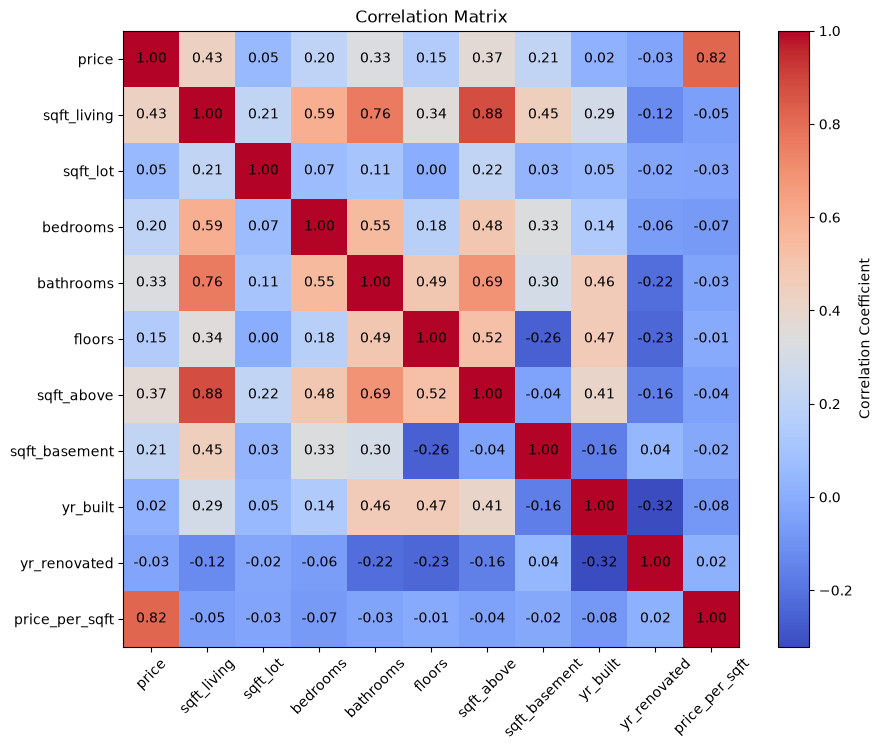

In [3]:
# Correlation matrix
corr_cols = ['price', 'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'floors', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'price_per_sqft']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')
plt.title('Correlation Matrix')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.show()

### Matriz de Correlación

**Descripción del gráfico:**
En base a las variables númericas del dataset correlacionables, se obtuvo el coeficiente de correlación de Pearson. Cada celda de la matriz representa la de relación entre las variables fila-columna, entre valores de -1 y 1.

**Hallazgos principales:**
- la correlación más alta encontrada es entre sqft_living y sqft_above siendo de 0.88, aunque no es un hallazgo que sorprenda ya que sqft_above es un subconjunto de sqft_living.
- Sorprendentemente, la correlación entre el precio de los hogares (price) y la cantidad de habitaciones que poseen (bedrooms) es relativamente baja, siendo de 0.20, mostrando que el precio de una vivienda no está justificado por la cantidad de habitaciones.
- Otra correlación que no acaba justificando el precio de un hogar es el de sqft_living y price_per_sqft, ya que su correlación es casi nula (-0,05). Esto demuestra que el precio por metro cuadrado de una casa no necesariamente se debe al tamaño de esta.
**Conclusión:**
Debería evitarse el uso de sqft_living y sqft_above ya que la información que aportan es poco relevante. Además, características como la cantidad de habitaciones o el tamaño de la vivienda poseen baja correlación con el precio, lo que sugiere que hay otras variables que tengan mayor influencia en ello, como la ubicación.

### Heatmaps

### Precio promedio por ciudad



             city  condition         price
0          Algona          3  2.016100e+05
1          Algona          4  2.300000e+05
2          Auburn          2  3.250000e+05
3          Auburn          3  3.263965e+05
4          Auburn          4  2.568732e+05
..            ...        ...           ...
129   Woodinville          3  6.294968e+05
130   Woodinville          4  5.895204e+05
131   Woodinville          5  5.268000e+05
132  Yarrow Point          3  1.901000e+06
133  Yarrow Point          4  9.594500e+05

[134 rows x 3 columns]


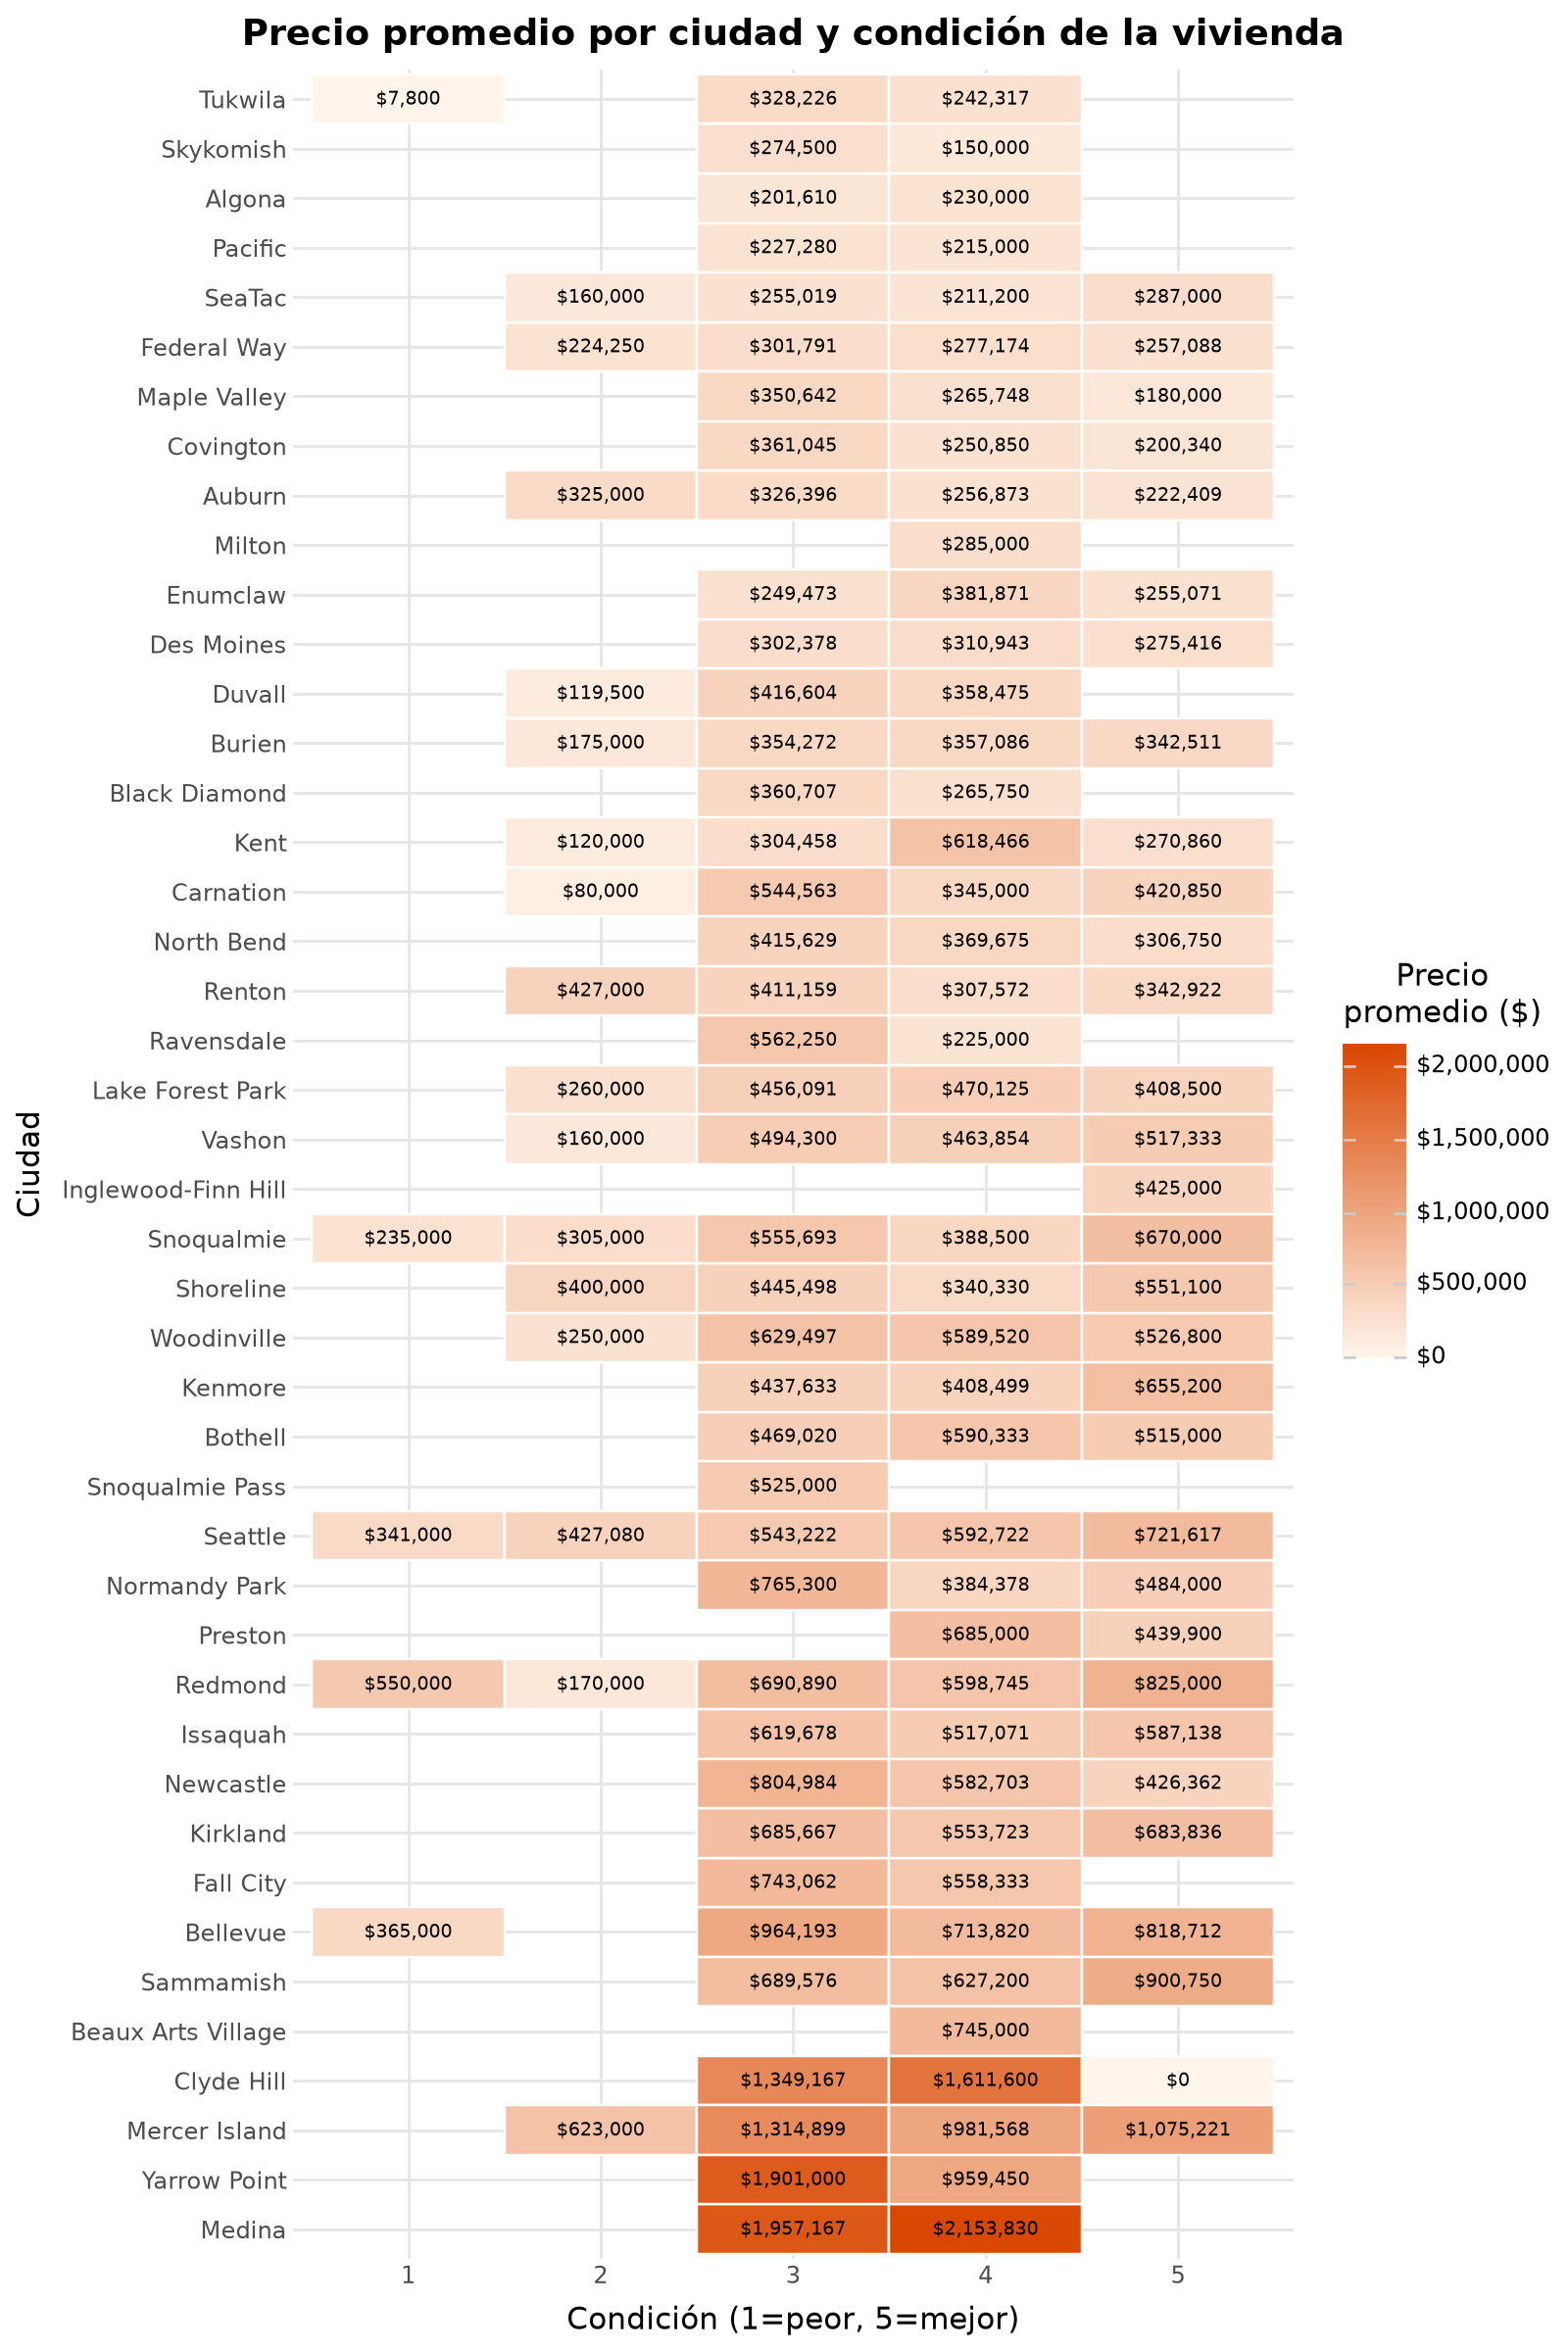

In [4]:
# precio promedio por ciudad y condicion
price_condition = (df.groupby(['city', 'condition'])['price']
                   .mean()
                   .reset_index())
ordered_cities = price_condition.groupby('city')['price'].mean().sort_values(ascending=False).index
price_condition['city'] = pd.Categorical(price_condition['city'], categories=ordered_cities, ordered=True)

print(price_condition)

chart = (
    ggplot(price_condition, aes(x='factor(condition)', y='city', fill='price'))
    + geom_tile(color='white', size=0.5)
    + geom_text(aes(label='price.round(0).astype(int)'), size=7, color='black', format_string='${:,}')
    + scale_fill_gradient(
        low='#fff5eb', 
        high='#d94801', 
        name='Precio\npromedio ($)',
        labels=lambda l: [f'${int(v):,}' for v in l]
    )
    + labs(
        title='Precio promedio por ciudad y condición de la vivienda',
        x='Condición (1=peor, 5=mejor)',
        y='Ciudad'
    )
    + theme_minimal()
    + theme(figure_size=(8, 12), plot_title=element_text(weight='bold'))
)

chart.show()

     bedrooms  bathrooms         price
0         0.0       0.00  1.195324e+06
1         1.0       0.75  2.715688e+05
2         1.0       1.00  2.551239e+05
3         1.0       1.25  5.165000e+05
4         1.0       1.50  3.100000e+05
..        ...        ...           ...
97        7.0       5.75  5.400000e+05
98        7.0       8.00  2.280000e+06
99        8.0       2.75  3.400000e+05
100       8.0       3.50  1.970000e+06
101       9.0       4.50  5.999990e+05

[102 rows x 3 columns]


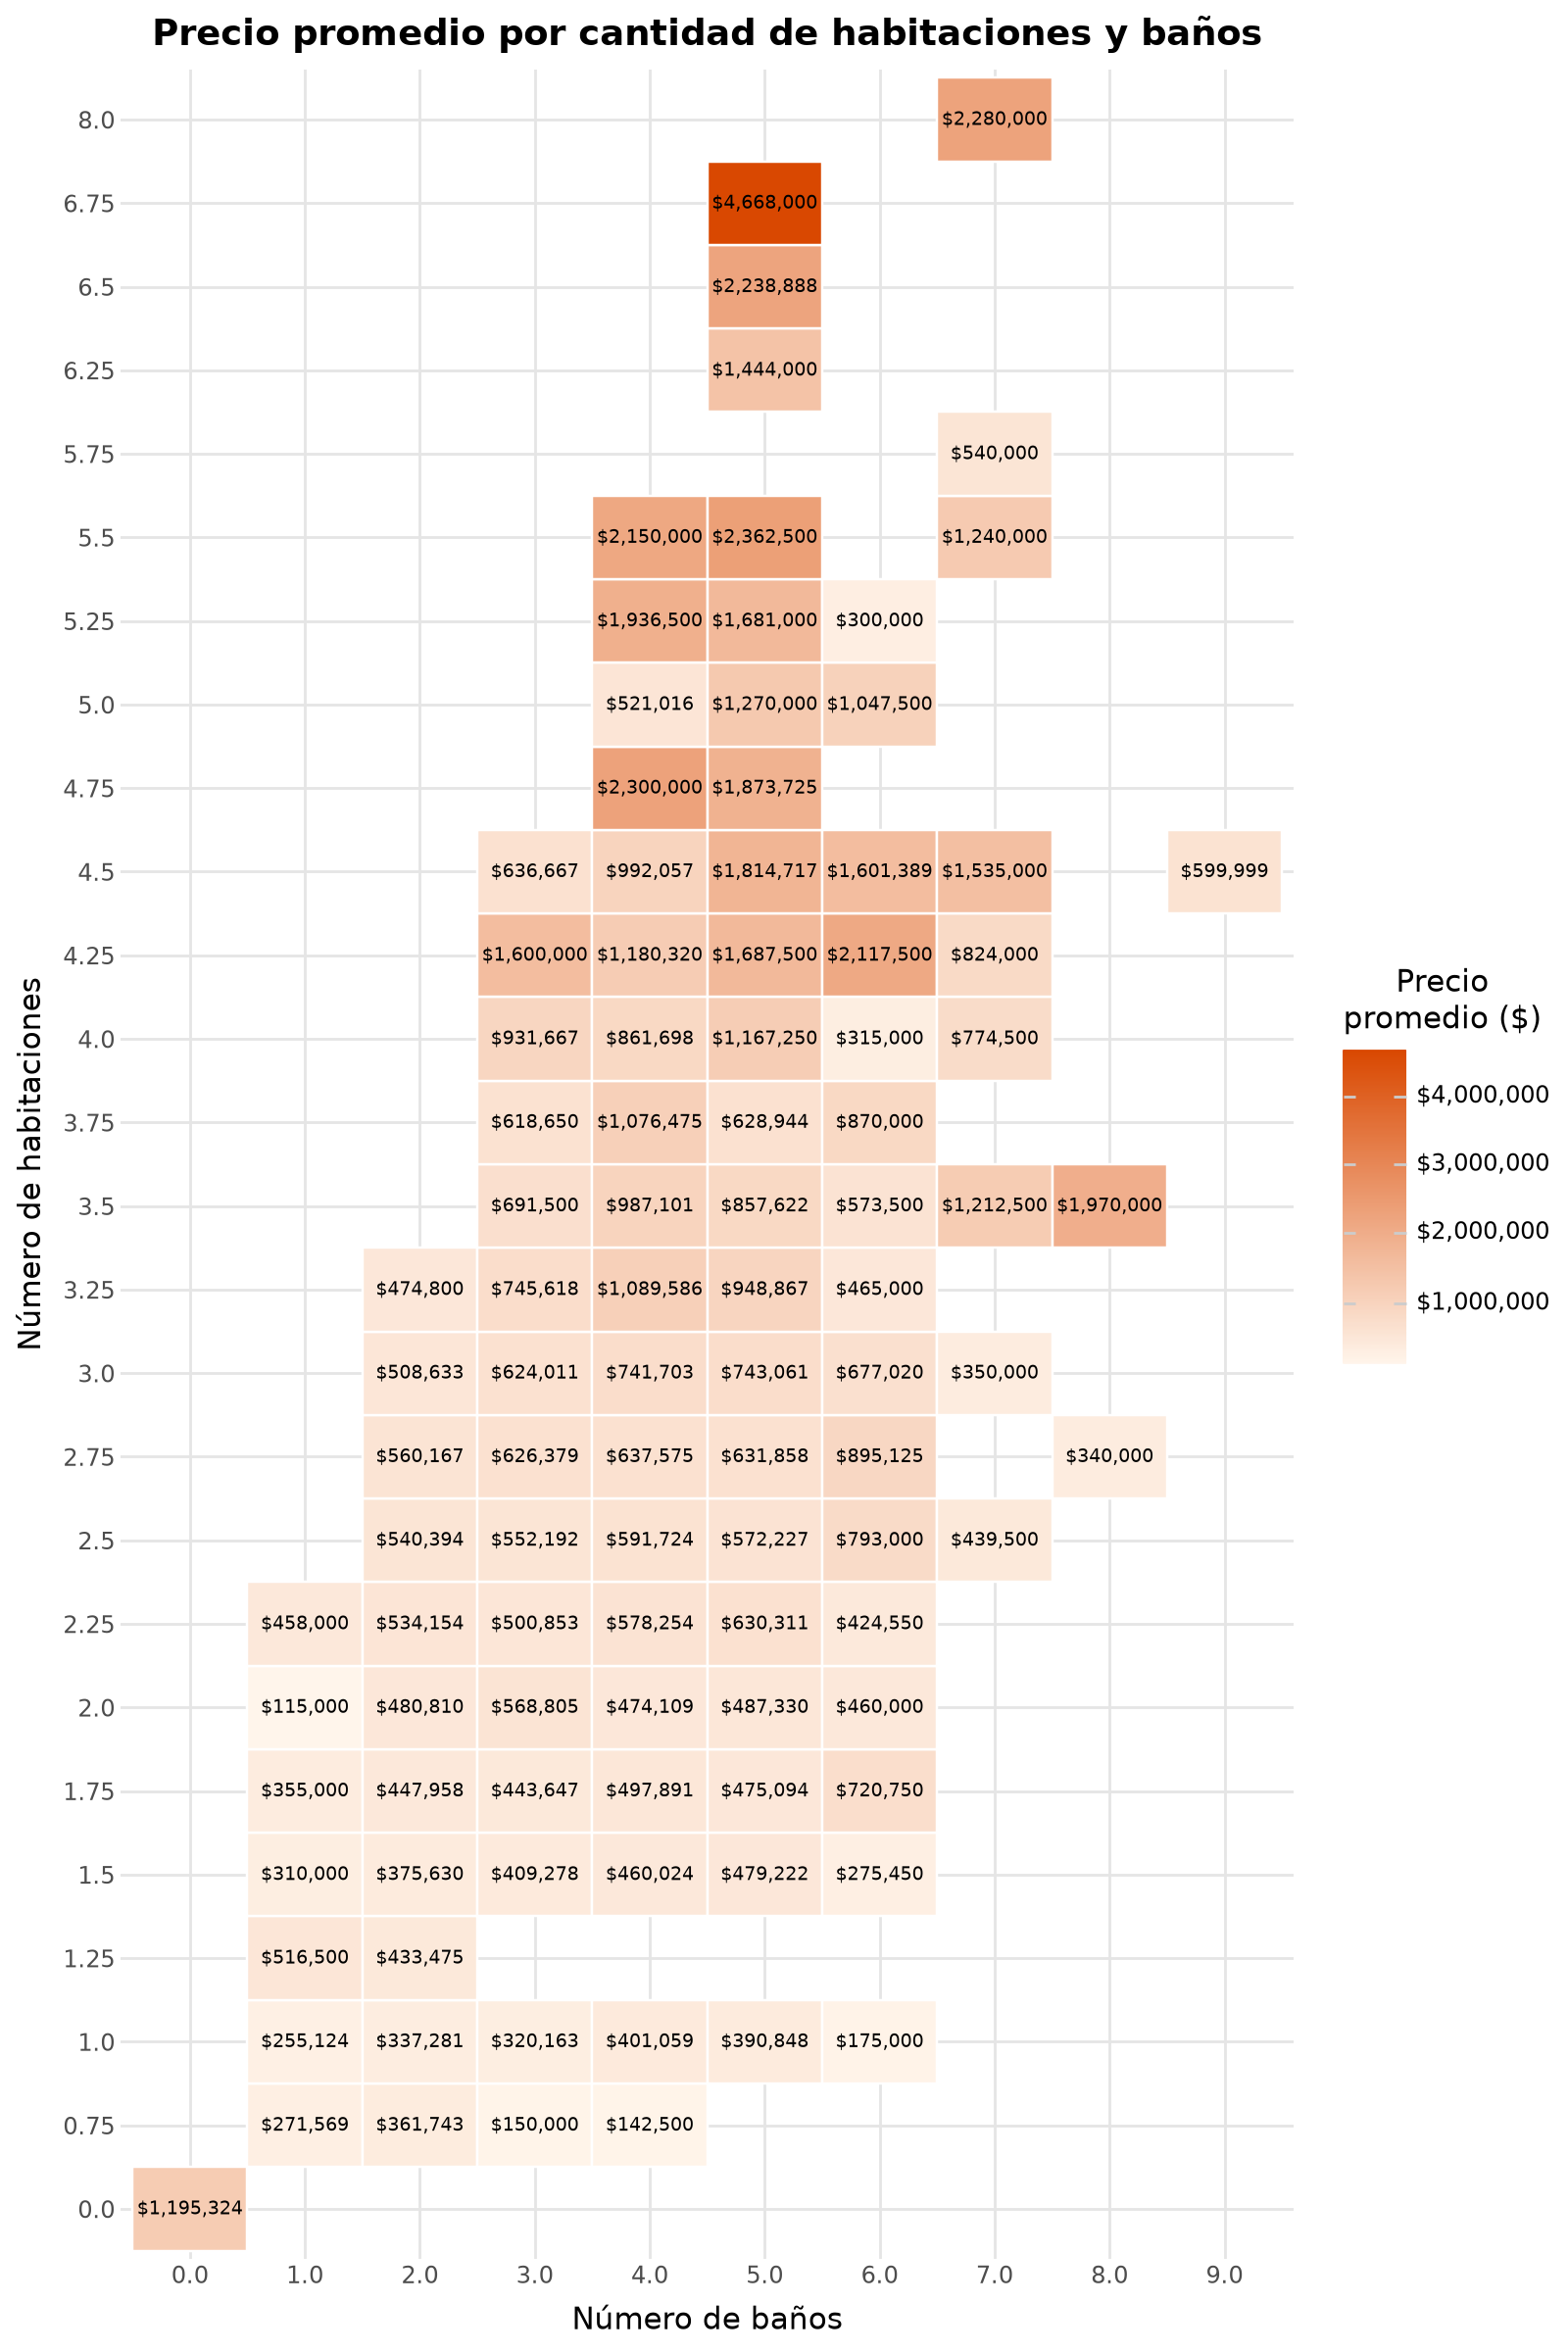

In [5]:
# heatmap de precio promedio por bedrooms y bathrooms

price_bed_bath = (df.groupby(['bedrooms', 'bathrooms'])['price']
                  .mean()
                  .reset_index())

print(price_bed_bath)

chart = (
    ggplot(price_bed_bath, aes(x='factor(bedrooms)', y='factor(bathrooms)', fill='price'))
    + geom_tile(color='white', size=0.5)
    + geom_text(aes(label='price.round(0).astype(int)'), size=7, color='black', format_string='${:,}')
    + scale_fill_gradient(
        low='#fff5eb', 
        high='#d94801', 
        name='Precio\npromedio ($)',
        labels=lambda l: [f'${int(v):,}' for v in l],
        limits=(price_bed_bath['price'].min(), price_bed_bath['price'].max())
    )
    + labs(
        title='Precio promedio por cantidad de habitaciones y baños',
        x='Número de baños',
        y='Número de habitaciones'
    )
    + theme_minimal()
    + theme(figure_size=(8, 12), plot_title=element_text(weight='bold'))
)

chart.show()

---

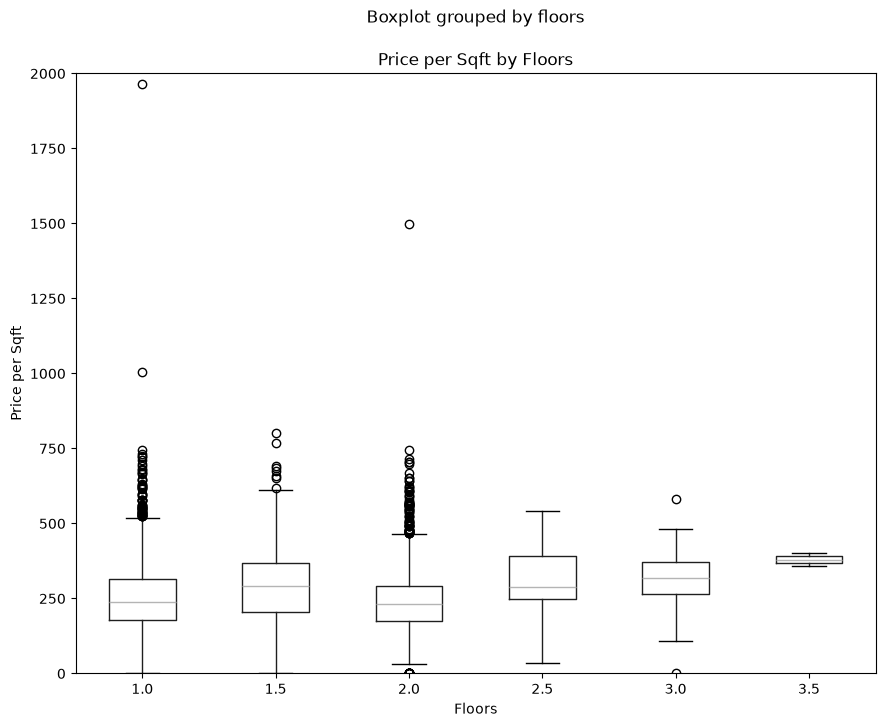

In [6]:
#boxplot of price per sqft by number of floors
df.boxplot(column='price_per_sqft', by='floors', grid=False, figsize=(10, 8))
plt.title('Price per Sqft by Floors')
plt.xlabel('Floors')
plt.ylim(0, 2000)
plt.ylabel('Price per Sqft')
plt.show()

### Boxplot Price per sqft por Número de Floors

**Descripción del gráfico:**
Para este gráfico se agrupó price_per_sqft en base al número de pisos de una vivienda. Se acotó el rango de price_per_sqft debido a valores atípicos extremos (superando valores de hasta 20000) que dificultaban la visualización de los datos.
**Hallazgos principales:**
- La mediana del precio por metro cuadrado muestra un ligero aumento mientras una vivienda poseyera más pisos.
- La mayoría de valores atípicos se concentran en las casas de 1 y 1.5 pisos, probablemente relacionado a otros factores como la zona en la que se encuentra.
- la caja de 3.5 pisos es la más compacta de todas, además de no contar con valores atípicos. Probablemente esto se deba a que hay pocos datos de viviendas en esta categoría.

**Conclusión:**
Se observa el aumento de la mediana en relación a la cantidad de pisos de la viviendas, lo cual podría sugerir que el precio por metro cuadrado si podría verse influenciado según la cantidad de pisos. Aún así, hay que tratar con cuidado esta información debido a los pocos datos dentro de las categorias de 3 y 3.5 pisos.

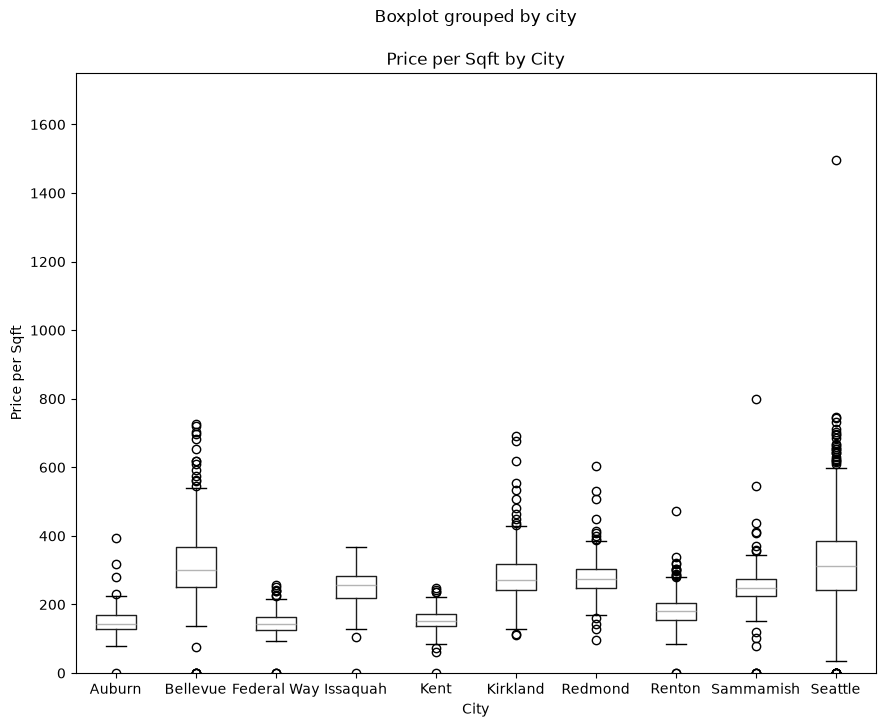

In [7]:
# boxplot of price per sqft by top 10 cities
cities = df['city'].value_counts().head(10).index
df_top = df[df['city'].isin(cities)]
df_top.boxplot(column='price_per_sqft', by='city', grid=False, figsize=(10, 8))
plt.title('Price per Sqft by City')
plt.xlabel('City')
plt.ylim(0, 1750)
plt.ylabel('Price per Sqft')
plt.show()


### Boxplot Price per sqft por City

**Descripción del gráfico:**
Para este gráfico, se agrupó el price_per_sqft en base al top 10 ciudades del dataset (city), para de esta manera comparar la distribución del precio por metro cuadrado de la vivienda según su ubicación. El rango de valores de price_per_sqft fue acotado debido a valores extremos (superiores a 5000 y a 20000) que distorsionaban la escala del gráfico y dificultaba la visualización del mismo.

**Hallazgos principales:**
- Se puede observar que los hogares mejor valorados por metro cuadrado están entre las ciudades de Seattle y Bellevue y Sammamish.
- Seattle y Bellevue son las ciudades que poseen más dispersión y valores atipicos. Esto podría deberse a la variabilidad de los precios segun la zona de dichas ciudades.
- Las ciudades más pequeñas como Kent o Auburn muestran cajas más compactas y consistentes.

**Conclusión:**
Con este boxplot podríamos considerar que la ubicación (city) es un factor relevante en la diferencia de precios por metro cuadrado de las viviendas, por lo que debería considerarse para análisis basados en el precio de viviendas.